In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
data = 'https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv'
!wget $data

--2026-05-27 18:51:44--  https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv.3’

CreditScoring.csv.3 100%[===================>] 178.21K  --.-KB/s    in 0.06s   

2026-05-27 18:51:45 (2.91 MB/s) - ‘CreditScoring.csv.3’ saved [182489/182489]



In [106]:
df = pd.read_csv('CreditScoring.csv')

In [107]:
df.columns = df.columns.str.lower()

In [108]:
# decoding categorical variables from R
df.status = df.status.map({1: 'ok', 2: 'default', 0: 'unknown'})

df.home = df.home.map({
    1: 'rent',
    2: 'owner',
    3: 'priv',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unknown'})

df.marital = df.marital.map({
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unknown'
})

df.records = df.records.map({
    1: 'no_rec',
    2: 'yes_rec'})

df.job = df.job.map({
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unknown'})

In [109]:
df[['marital', 'home', 'status', 'records', 'job']] = df[['marital', 'home', 'status', 'records', 'job']].astype('str') #convert string fields into string data types

In [110]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no_rec,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no_rec,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes_rec,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no_rec,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no_rec,fixed,46,107,0,0,310,910


In [111]:
df.dtypes

,0
status,object
seniority,int64
home,object
time,int64
age,int64
marital,object
records,object
job,object
expenses,int64
income,int64


In [112]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [113]:
numericals = list(df.dtypes[df.dtypes == 'int'].index) #list of numerical columns

In [114]:
for col in numericals:
    df[col] = df[col].replace(df[col].max(), np.nan)

In [115]:
df[numericals].isnull().sum()

,0
seniority,1
time,1
age,2
expenses,1
income,34
assets,47
debt,18
amount,1
price,1


In [116]:
for col in numericals:
    df[col] = df[col].fillna(df[col].median())

In [117]:
df.isnull().sum()

,0
status,0
seniority,0
home,0
time,0
age,0
marital,0
records,0
job,0
expenses,0
income,0


### check for outliers in numerical columns

In [118]:

df.kurtosis(numeric_only=True)

,0
seniority,1.741537
time,-0.434421
age,-0.631137
expenses,1.123040
income,10.155712
assets,182.062800
debt,149.892935
amount,3.710490
price,15.656248


In [119]:
df[['income', 'assets', 'debt', 'amount', 'price']].describe()

,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,130.487542,5378.077890,341.562963,1038.123906,1460.689338
std,86.042072,11514.557029,1243.532086,470.816388,611.120065
min,0.000000,0.000000,0.000000,100.000000,105.000000
25%,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,164.000000,6000.000000,0.000000,1300.000000,1691.000000
max,959.000000,300000.000000,30000.000000,4500.000000,8800.000000


In [120]:
from IPython.display import display

In [121]:
'''
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    print(col)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outlier = df[col][(df[col] < lower_bound) | (df[col] > upper_bound )]

    display(df_outlier)
    print(len(df_outlier))'''

"\nfor col in ['income', 'assets', 'debt', 'amount', 'price']:\n    print(col)\n    Q1 = df[col].quantile(0.25)\n    Q3 = df[col].quantile(0.75)\n    IQR = Q3 - Q1\n\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n    df_outlier = df[col][(df[col] < lower_bound) | (df[col] > upper_bound )]\n\n    display(df_outlier)\n    print(len(df_outlier))"

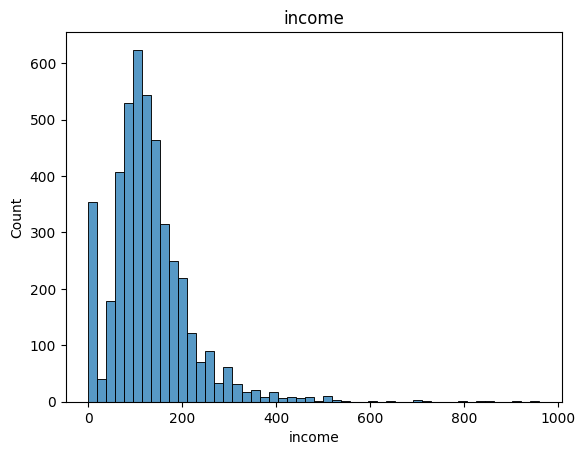

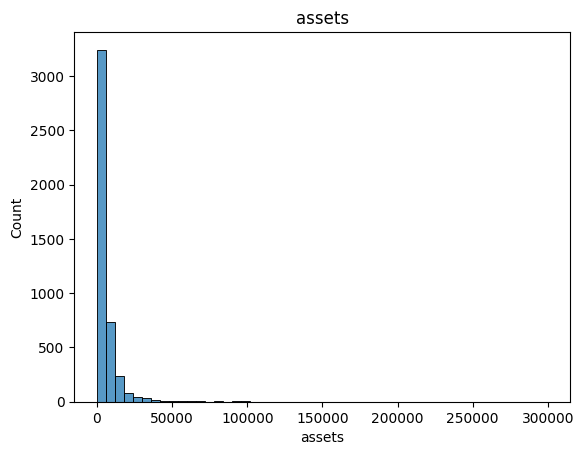

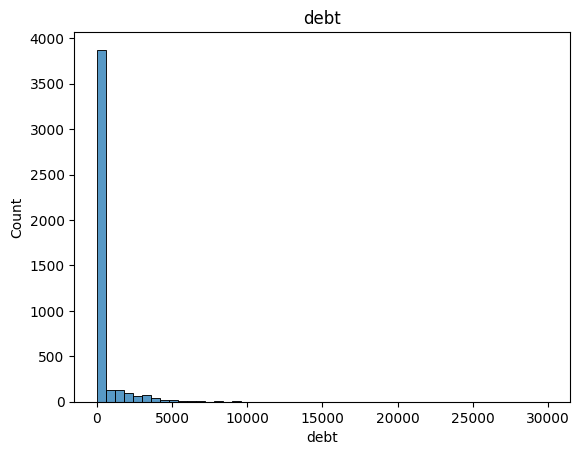

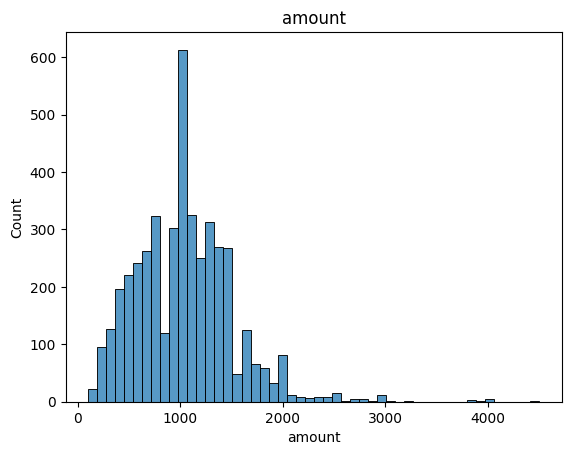

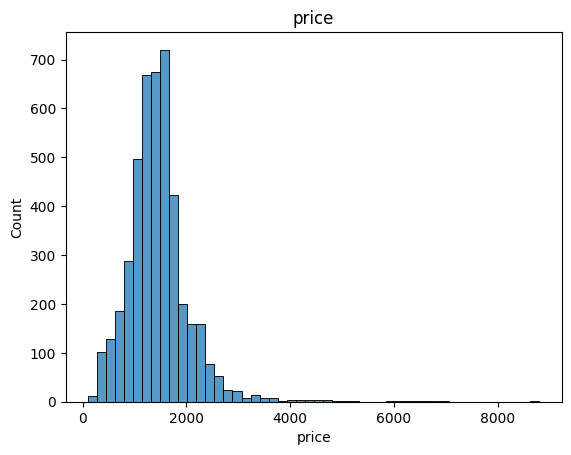

In [122]:
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(col)
    plt.show()


In [123]:
'''
for col in ['income', 'assets', 'debt', 'amount', 'price']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound) '''

"\nfor col in ['income', 'assets', 'debt', 'amount', 'price']:\n    \n    Q1 = df[col].quantile(0.25)\n    Q3 = df[col].quantile(0.75)\n    IQR = Q3 - Q1\n\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n    df[col] = df[col].clip(lower_bound, upper_bound) "

In [124]:
df[['income', 'assets', 'debt', 'amount', 'price']].describe()

,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,130.487542,5378.077890,341.562963,1038.123906,1460.689338
std,86.042072,11514.557029,1243.532086,470.816388,611.120065
min,0.000000,0.000000,0.000000,100.000000,105.000000
25%,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,164.000000,6000.000000,0.000000,1300.000000,1691.000000
max,959.000000,300000.000000,30000.000000,4500.000000,8800.000000


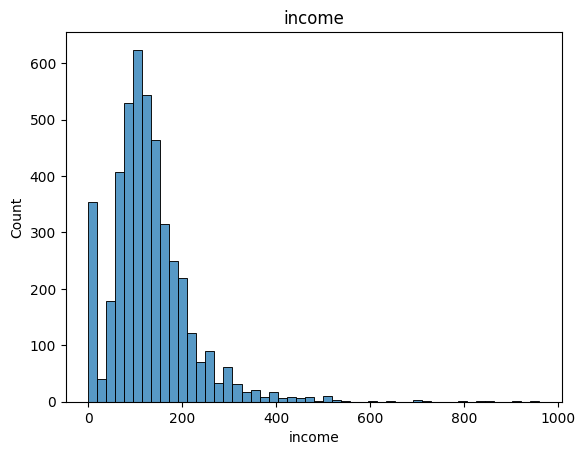

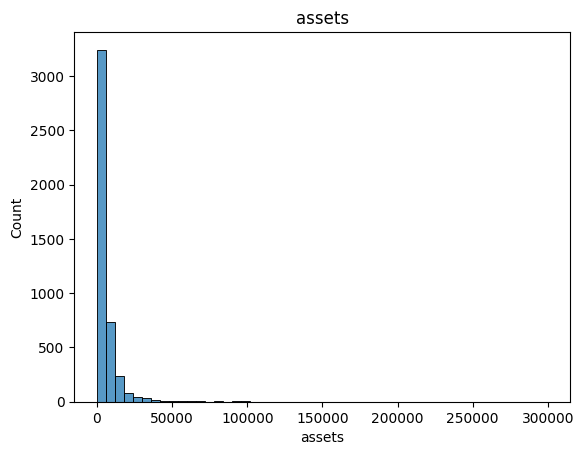

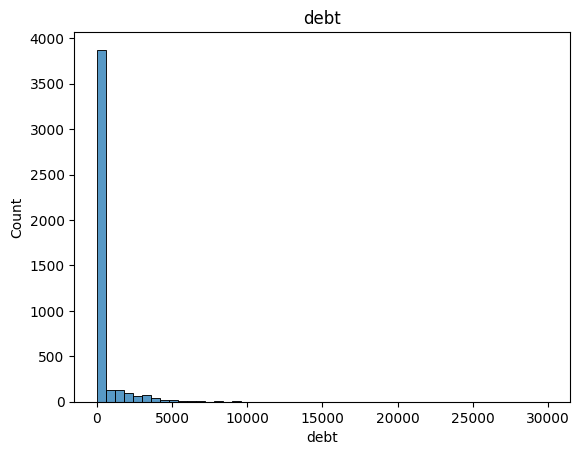

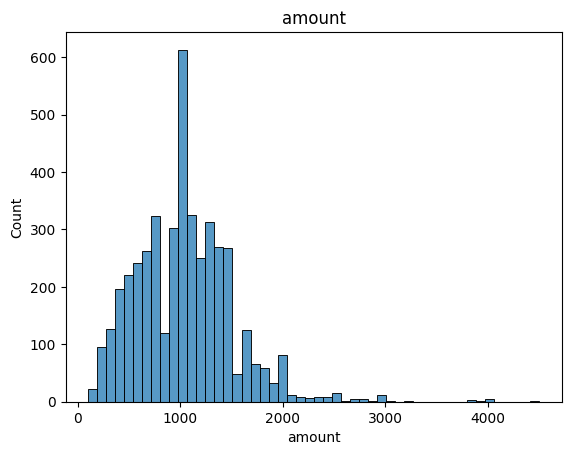

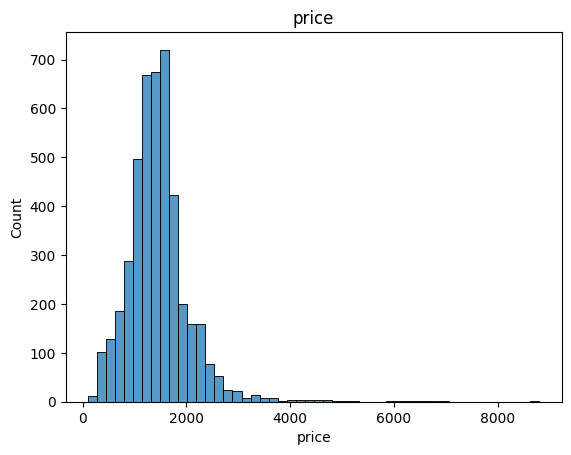

In [125]:
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(col)
    plt.show()


In [126]:
# correlation

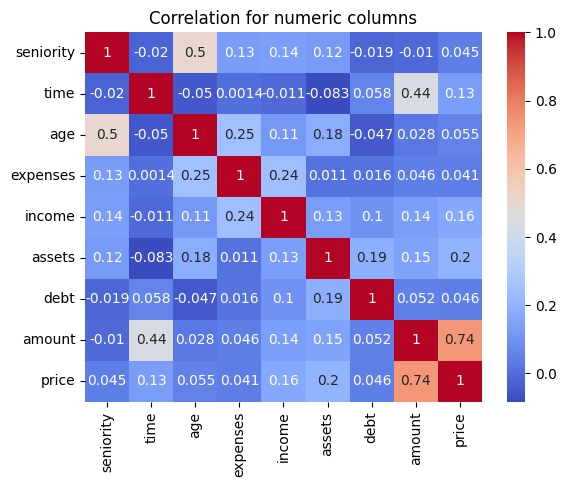

In [127]:
#from the correlatioin heatmap we can see that the price of an item is highly correlated to the amount
# of the loan this makes sence. since the more expensive the item the client wants to buy the more money the client will need
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation for numeric columns')
plt.show()

# Random Forest training

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [129]:
df['status'] = (df['status'] == 'default').astype('int')
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9.0,rent,60.0,30.0,married,no_rec,freelance,73.0,129.0,0.0,0.0,800.0,846.0
1,0,17.0,rent,60.0,58.0,widow,no_rec,fixed,48.0,131.0,0.0,0.0,1000.0,1658.0
2,1,10.0,owner,36.0,46.0,married,yes_rec,freelance,90.0,200.0,3000.0,0.0,2000.0,2985.0
3,0,0.0,rent,60.0,24.0,single,no_rec,fixed,63.0,182.0,2500.0,0.0,900.0,1325.0
4,0,0.0,rent,36.0,26.0,single,no_rec,fixed,46.0,107.0,0.0,0.0,310.0,910.0


In [130]:
#split the data

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [131]:
y_train = df_train['status'].values
y_test = df_test['status'].values
y_val = df_val['status'].values

In [132]:
del df_train['status']
del df_test['status']
del df_val['status']

In [133]:
len(df_train), len(df_test), len(df_val)

(2673, 891, 891)

In [134]:
from sklearn.feature_extraction import DictVectorizer

In [135]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

In [136]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

In [137]:
#model training
model = RandomForestClassifier(random_state=1,)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [138]:
#testing the model
y_pred = model.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
auc

np.float64(0.8263871469422567)

In [146]:
#Tuning max_depth parameter
score = []
for d in  [2,3,4,5,6,10,15,20]:
    model = RandomForestClassifier(random_state=1, max_depth=d)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    score.append((d, auc))

In [140]:
df_scores = pd.DataFrame(score, columns=[['max_depth', 'auc']])

In [141]:
model = RandomForestClassifier(random_state=1, max_depth=6)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
auc

np.float64(0.8306639743139516)

In [142]:
score = []
for s in [2,3,5,10]:
    for e in range(10, 201, 10):
        model = RandomForestClassifier(n_jobs=-1, random_state=1, max_depth=6, min_samples_leaf=s, n_estimators=e)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        score.append((s, e, auc))

In [143]:
df_scores = pd.DataFrame(score, columns=[['min_samples_leaf', 'n_estimators', 'auc' ]])
df_scores

,min_samples_leaf,n_estimators,auc
0,2,10,0.815902
1,2,20,0.822850
2,2,30,0.827328
3,2,40,0.830024
4,2,50,0.830338
...,...,...,...
75,10,160,0.834383
76,10,170,0.834063
77,10,180,0.833498
78,10,190,0.833335


In [144]:
df_scores.columns = df_scores.columns.get_level_values(0)
df_scores_pivot = df_scores.pivot(index='n_estimators', columns='min_samples_leaf', values='auc')

df_scores_pivot

min_samples_leaf,2,3,5,10
n_estimators,,,,
10,0.815902,0.822621,0.824126,0.827033
20,0.822850,0.828990,0.827350,0.829645
30,0.827328,0.832740,0.830407,0.830074
40,0.830024,0.833279,0.831680,0.833511
50,0.830338,0.832526,0.830332,0.833128
60,0.831115,0.832853,0.831034,0.833975
70,0.832131,0.832169,0.831623,0.835480
80,0.832094,0.831705,0.832633,0.835311
90,0.831580,0.830582,0.832514,0.834703


<Axes: xlabel='min_samples_leaf', ylabel='n_estimators'>

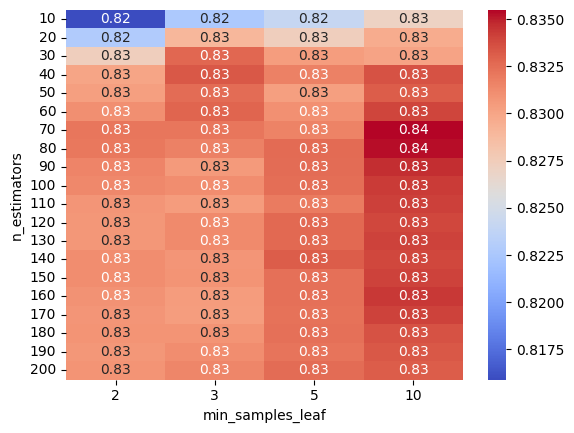

In [145]:
sns.heatmap(df_scores_pivot, annot=True, cmap='coolwarm')

In [158]:
#final model
model = RandomForestClassifier(n_jobs=-1, random_state=1, max_depth=6, min_samples_leaf=10, n_estimators=70)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
auc

np.float64(0.8354801083630161)

In [159]:
# Testing the model
test_dicts = df_test.to_dict(orient='records')

In [149]:
X_test = dv.transform(test_dicts)

In [163]:
y_pred_t = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_t)
auc

np.float64(0.8070159324981324)